# Stock Return Prediction — Modelling Pipeline

**Objective:** Predict 5-day forward returns for 87 US-listed stocks using ML models trained on:
- ~150 technical/momentum/volatility features per ticker
- ~106 macro-economic features (FRED + cross-asset + ETF flows)
- Per-ticker alternative data (SEC EDGAR insider trades, analyst revisions)
- News sentiment (VADER) + embeddings (MiniLM 384-dim → PCA 20)

**Evaluation:** Temporal train/test split (pre-2025 / 2025+), no shuffling. Key metrics: RMSE improvement over zero-baseline, directional accuracy, Spearman IC.

## 0. Configuration

All tuneable parameters in one place. Change these and "Run All" to reproduce.

In [2]:
# ── Parameters ──────────────────────────────────────────────────────────────
START_DATE      = "2021-01-01"
END_DATE        = "2025-09-25"
SPLIT_DATE      = "2025-01-01"      # temporal train/test boundary
TARGET_HORIZON  = 5                  # 5-day forward return
CORR_THRESHOLD  = 0.99              # drop features with |ρ| > this
SPARSE_THRESH   = 0.10              # drop columns with > 10% NaN
N_PCA_COMPONENTS = 20               # PCA dims for news embeddings

## 1. Imports & Setup

In [3]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore', category=FutureWarning)

from scipy.stats import spearmanr
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error
import sklearn
sklearn.set_config(transform_output="pandas")

from data.data_loader import StockDataLoader
from features.feature_engineering import FeatureEngineer
from data.news import get_news, batch_get_news
from data.alternative import get_macro_data, get_alternative_data

## 2. Ticker Universe

87 liquid US-listed stocks across 11 sectors + 17 sector/thematic ETFs (used as features only).

In [4]:
# ── Stocks ──────────────────────────────────────────────────────────────────
stock_tickers = [
    # Technology
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "TSLA",
    "ORCL", "CRM", "ADBE", "INTC", "AMD", "QCOM", "AVGO", "IBM", "TXN", "NOW",
    # Finance
    "JPM", "BAC", "WFC", "GS", "C", "MS", "AXP", "BLK", "SCHW", "V", "MA", "PYPL",
    # Healthcare
    "JNJ", "PFE", "MRK", "UNH", "ABBV", "LLY", "BMY", "AMGN", "GILD",
    # Energy
    "XOM", "CVX", "COP", "SLB", "SHEL", "EOG", "PSX", "VLO",
    # Consumer & Retail
    "WMT", "TGT", "HD", "LOW", "NKE", "COST", "SBUX", "KO", "PEP", "MCD", "PG",
    # Entertainment & Media
    "DIS", "NFLX", "CMCSA",
    # Industrials
    "CAT", "GE", "BA", "HON", "LMT", "RTX", "DE", "UNP", "FDX", "UPS",
    # Telecom
    "VZ", "T", "TMUS",
    # Utilities
    "NEE", "DUK", "SO",
    # Materials
    "LIN", "FCX", "NEM",
    # Real Estate
    "PLD", "AMT", "SPG", "O",
    # International (liquid US-listed ADRs)
    "BABA", "TSM", "SHOP", "MELI",
]

# ── ETFs (used as features via FeatureEngineer, not as prediction targets) ──
etfs = [
    "SPY", "QQQ",
    "XLK", "XLF", "XLV", "XLE", "XLY", "XLP",
    "XLC", "XLI", "XLU", "XLB", "XLRE",
    "SMH", "IYR",
    "EEM", "FXI",
]

# ── Sector ETF map (ticker → relevant ETFs for relative strength features) ──
ticker_to_etf = {
    **{t: ["QQQ", "XLK", "SPY"] for t in ["AAPL", "MSFT", "ORCL", "CRM", "ADBE", "IBM", "NOW"]},
    **{t: ["QQQ", "XLK", "SMH", "SPY"] for t in ["NVDA", "INTC", "AMD", "QCOM", "AVGO", "TXN"]},
    "GOOGL": ["QQQ", "XLC", "SPY"], "AMZN": ["QQQ", "XLY", "SPY"],
    "META": ["QQQ", "XLC", "SPY"], "TSLA": ["QQQ", "XLY", "SPY"],
    **{t: ["XLF", "SPY"] for t in ["JPM", "BAC", "WFC", "GS", "C", "MS", "AXP", "BLK", "SCHW", "V", "MA", "PYPL"]},
    **{t: ["XLV", "SPY"] for t in ["JNJ", "PFE", "MRK", "UNH", "ABBV", "LLY", "BMY", "AMGN", "GILD"]},
    **{t: ["XLE", "SPY"] for t in ["XOM", "CVX", "COP", "SLB", "SHEL", "EOG", "PSX", "VLO"]},
    **{t: ["XLP", "SPY"] for t in ["WMT", "TGT", "COST", "KO", "PEP", "PG"]},
    **{t: ["XLY", "SPY"] for t in ["HD", "LOW", "NKE", "SBUX", "MCD"]},
    **{t: ["XLC", "SPY"] for t in ["DIS", "NFLX", "CMCSA"]},
    **{t: ["XLI", "SPY"] for t in ["CAT", "GE", "BA", "HON", "LMT", "RTX", "DE", "UNP", "FDX", "UPS"]},
    **{t: ["XLC", "SPY"] for t in ["VZ", "T", "TMUS"]},
    **{t: ["XLU", "SPY"] for t in ["NEE", "DUK", "SO"]},
    **{t: ["XLB", "SPY"] for t in ["LIN", "FCX", "NEM"]},
    **{t: ["XLRE", "IYR", "SPY"] for t in ["PLD", "AMT", "SPG", "O"]},
    "BABA": ["EEM", "FXI"], "TSM": ["EEM", "QQQ"],
    "SHOP": ["XLY", "QQQ", "SPY"], "MELI": ["EEM"],
}

all_tickers = stock_tickers + etfs
print(f"Stocks: {len(stock_tickers)}, ETFs: {len(etfs)}, Total: {len(all_tickers)}")

Stocks: 87, ETFs: 17, Total: 104


## 3. Data Loading

Four data sources, loaded independently and merged in Section 4:

| Source | Granularity | Features | Leakage Prevention |
|--------|------------|----------|-------------------|
| **Price + Technical** | per ticker-day | ~150 technical/momentum/vol features | Raw OHLCV dropped; all features use lagged windows |
| **Macro** | per day (global) | ~106 FRED + cross-asset + ETF flow features | FRED has publication lag; forward-filled point-in-time |
| **Alternative** | per ticker-day | EDGAR insider trades, analyst revisions | Historical filings; no future data |
| **News** | per ticker-day | VADER sentiment + 384-dim MiniLM embeddings | Shifted +1 day (only yesterday's news at prediction time) |

In [5]:
# ── 3a. Price + Technical Features ──────────────────────────────────────────
# StockDataLoader: downloads OHLCV via yfinance
# FeatureEngineer: adds ~150 features (SMA ratios, RSI, MACD, Bollinger,
#   ATR, volume ratios, ETF relative strength, cross-sectional ranks, etc.)
#   Creates target = close[t+H]/close[t] - 1  (H = TARGET_HORIZON)
#   Drops raw OHLCV via remove_today_features() to prevent leakage

data_loader = make_pipeline(
    StockDataLoader(symbols=all_tickers, start_date=START_DATE, end_date=END_DATE),
    FeatureEngineer(
        etf_columns=etfs,
        sector_map=ticker_to_etf,
        target_horizon=TARGET_HORIZON,
    ),
)

df = data_loader.transform(X=None)
df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")

print(f"Price + technical: {df.shape}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"Tickers: {df['symbol'].nunique()}")

[*********************100%***********************]  104 of 104 completed
INFO:data.data_loader:Successfully combined data for 104 symbols: 123448 total records
INFO:features.feature_engineering:Added 151 new features
INFO:features.feature_engineering:Added 150 new features
INFO:features.feature_engineering:Added 151 new features
INFO:features.feature_engineering:Added 152 new features
INFO:features.feature_engineering:Added 150 new features
INFO:features.feature_engineering:Added 151 new features
INFO:features.feature_engineering:Added 151 new features
INFO:features.feature_engineering:Added 152 new features
INFO:features.feature_engineering:Added 150 new features
INFO:features.feature_engineering:Added 150 new features
INFO:features.feature_engineering:Added 150 new features
INFO:features.feature_engineering:Added 150 new features
INFO:features.feature_engineering:Added 150 new features
INFO:features.feature_engineering:Added 150 new features
INFO:features.feature_engineering:Added 15

Price + technical: (103269, 185)
Date range: 2021-01-04 → 2025-09-24
Tickers: 87


In [6]:
# ── 3b. Macro Features (ticker-agnostic) ────────────────────────────────────
# ~55 FRED series → ~106 derived features: yield curve, VIX regime, credit
# spreads, labor market, inflation, currency, cross-asset (BTC, copper/gold),
# ETF fund flow proxies (SPY/QQQ/IWM/HYG/TLT abnormal volume)

macro = get_macro_data(START_DATE, END_DATE)
print(f"Macro features: {macro.shape}")

INFO:data.alternative.pipeline:Fetching expanded macro data (2021-01-01 → 2025-09-25) …
INFO:data.alternative.scrapers:  FRED progress: 10/50 series downloaded
INFO:data.alternative.scrapers:  FRED progress: 20/50 series downloaded
INFO:data.alternative.scrapers:  FRED progress: 30/50 series downloaded
INFO:data.alternative.scrapers:  FRED progress: 40/50 series downloaded
INFO:data.alternative.scrapers:  FRED progress: 50/50 series downloaded
INFO:data.alternative.scrapers:Cached 1235 rows → macro_expanded_GLOBAL_2021-01-01_2025-09-25_426a0a4c.parquet
INFO:data.alternative.scrapers:Expanded macro: 1235 rows × 50 cols (1 series failed: GOLDAMGBD228NLBM)
INFO:data.alternative.scrapers:Cached 1235 rows → cross_asset_GLOBAL_2021-01-01_2025-09-25_c6063e46.parquet
INFO:data.alternative.scrapers:Cross-asset data: 1235 rows × 3 columns
INFO:data.alternative.pipeline:Cross-asset data merged: +2 columns
INFO:data.alternative.scrapers:Cached 1235 rows → etf_flows_GLOBAL_2021-01-01_2025-09-25_b5b

Macro features: (1235, 183)


In [50]:
# ── 3c. Per-Ticker Alternative Data ─────────────────────────────────────────
# SEC EDGAR Form 4: insider buy/sell counts, dollar values, officer breakdowns
# Analyst revisions: upgrade/downgrade counts from Yahoo Finance
# Also fetches institutional holdings, earnings, congress trades, pageviews

alt_df = get_alternative_data(stock_tickers, START_DATE, END_DATE)
alt_df = alt_df.rename(columns={"ticker": "symbol"})
print(f"Alternative data: {alt_df.shape}")
print(f"Columns: {sorted(alt_df.columns.tolist())}")

INFO:data.alternative.pipeline:Batch alternative data for 87 tickers …
INFO:data.alternative.scrapers:Found 500 Form 4 filing URLs for CIK 0000789019
INFO:data.alternative.scrapers:Found 500 Form 4 filing URLs for CIK 0001652044
INFO:data.alternative.scrapers:Found 198 Form 4 filing URLs for CIK 0000320193
INFO:data.alternative.scrapers:Found 443 Form 4 filing URLs for CIK 0001045810
INFO:data.alternative.scrapers:  MSFT: parsed 150/500 filings (106 transactions so far)
INFO:data.alternative.scrapers:  NVDA: parsed 150/443 filings (454 transactions so far)
INFO:data.alternative.scrapers:  AAPL: parsed 150/198 filings (197 transactions so far)
INFO:data.alternative.scrapers:  GOOGL: parsed 150/500 filings (226 transactions so far)
INFO:data.alternative.scrapers:AAPL: parsed 85 filings → 246 transactions
INFO:data.alternative.scrapers:Cached 45 rows → insider_edgar_AAPL_2021-01-01_2025-09-25_0fc7179f.parquet
INFO:data.alternative.scrapers:  ✓ insider → 45 rows for AAPL
INFO:data.alternat

Alternative data: (107445, 40)
Columns: ['analyst_buy_pct', 'analyst_consensus_score', 'analyst_total', 'avg_call_iv', 'avg_put_iv', 'date', 'days_since_earnings', 'days_to_next_earnings', 'earnings_beat', 'earnings_surprise_ma', 'earnings_surprise_pct', 'insider_activity_5d', 'insider_buy_ratio', 'insider_buy_value_30d', 'insider_buys_30d', 'insider_net_transactions', 'insider_net_value_30d', 'insider_officer_buy_ratio', 'insider_sells_30d', 'iv_skew', 'iv_skew_signal', 'oi_put_call_ratio', 'options_sentiment', 'put_call_ratio', 'revision_activity', 'revision_downgrades_30d', 'revision_momentum', 'revision_net_30d', 'revision_sentiment', 'revision_upgrades_30d', 'short_crowding_score', 'short_interest_mom_change', 'short_pct_float', 'short_ratio', 'short_squeeze_risk', 'symbol', 'wiki_attention_spike', 'wiki_attention_trend', 'wiki_pageviews', 'wiki_pageviews_ma7']


In [49]:
alt_df

,date,symbol,insider_net_transactions,insider_buy_ratio,insider_buys_30d,insider_sells_30d,insider_activity_5d,insider_buy_value_30d,insider_net_value_30d,insider_officer_buy_ratio,earnings_surprise_pct,earnings_beat,days_since_earnings,days_to_next_earnings,earnings_surprise_ma,analyst_consensus_score,analyst_buy_pct,analyst_total,short_pct_float,short_ratio,short_interest_mom_change,short_squeeze_risk,short_crowding_score,put_call_ratio,oi_put_call_ratio,avg_call_iv,avg_put_iv,iv_skew,options_sentiment,iv_skew_signal,wiki_pageviews,wiki_pageviews_ma7,wiki_attention_spike,wiki_attention_trend,revision_upgrades_30d,revision_downgrades_30d,revision_net_30d,revision_momentum,revision_activity,revision_sentiment
0,2021-01-01,AAPL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,474.0,NaN,3.562500,0.604167,48,0.0088,2.41,0.108677,0,0.0329,0.449133,0.744624,0.324321,0.372351,0.04803,0.550867,0.240149,12694.0,12694.000000,0.0,1.000000,0.0,0.0,0.0,0.000000,0,0.000000
1,2021-01-04,AAPL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,473.0,NaN,3.562500,0.604167,48,0.0088,2.41,0.108677,0,0.0329,0.449133,0.744624,0.324321,0.372351,0.04803,0.550867,0.240149,17389.0,15069.750000,0.0,1.001878,0.0,0.0,0.0,0.000000,0,0.000000
2,2021-01-05,AAPL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,472.0,NaN,3.562500,0.604167,48,0.0088,2.41,0.108677,0,0.0329,0.449133,0.744624,0.324321,0.372351,0.04803,0.550867,0.240149,17277.0,15511.200000,0.0,0.982551,1.0,0.0,1.0,0.666667,1,0.500000
3,2021-01-06,AAPL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,471.0,NaN,3.562500,0.604167,48,0.0088,2.41,0.108677,0,0.0329,0.449133,0.744624,0.324321,0.372351,0.04803,0.550867,0.240149,17094.0,15775.000000,0.0,0.978993,1.0,0.0,1.0,0.666667,1,0.333333
4,2021-01-07,AAPL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,470.0,NaN,3.562500,0.604167,48,0.0088,2.41,0.108677,0,0.0329,0.449133,0.744624,0.324321,0.372351,0.04803,0.550867,0.240149,17139.0,15969.857143,0.0,0.978629,1.0,0.0,1.0,0.666667,1,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107440,2025-09-19,XOM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.734104,NaN,100.0,NaN,4.345177,3.666667,0.481481,27,0.0130,2.17,-0.058087,0,0.0347,0.293028,1.331317,0.397336,0.380726,-0.01661,0.706972,-0.083051,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000000,1,0.000000
107441,2025-09-22,XOM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.734104,NaN,101.0,NaN,4.345177,3.666667,0.481481,27,0.0130,2.17,-0.058087,0,0.0347,0.293028,1.331317,0.397336,0.380726,-0.01661,0.706972,-0.083051,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000000,0,0.000000
107442,2025-09-23,XOM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.734104,NaN,102.0,NaN,4.345177,3.666667,0.481481,27,0.0130,2.17,-0.058087,0,0.0347,0.293028,1.331317,0.397336,0.380726,-0.01661,0.706972,-0.083051,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000000,0,0.000000
107443,2025-09-24,XOM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.734104,NaN,103.0,NaN,4.345177,3.666667,0.481481,27,0.0130,2.17,-0.058087,0,0.0347,0.293028,1.331317,0.397336,0.380726,-0.01661,0.706972,-0.083051,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000000,0,0.000000


In [63]:
# ── 3d. News Sentiment + Embeddings ─────────────────────────────────────────
# VADER: fast rule-based sentiment (mean/median/std/min/max + count)
# MiniLM (all-MiniLM-L6-v2): 384-dim sentence embeddings, daily avg per ticker
# First run: ~5 min (embedding computation). Subsequent runs: instant (cached).

NEWS_CACHE_DIR = os.path.join(os.path.dirname(os.getcwd()), "datasets", "cache")

news_df = get_news(
    stock_tickers,
    start_date=START_DATE,
    end_date=END_DATE,
    sentiment_method="vader",   

    vectorize_method="finbert_embedding",
    aggregate=True,
    use_cache=True,
    result_cache_dir=NEWS_CACHE_DIR,
)

print(f"News features: {news_df.shape}")
emb_count = sum(1 for c in news_df.columns if c.startswith("emb_"))
print(f"Embedding dimensions: {emb_count}")

INFO:data.news.pipeline:Batch processing 87 tickers …
INFO:data.news.scraper:Cache hit: AAPL_2021-01-01_2025-09-25_5bee77c8.parquet
INFO:data.news.scraper:Cache hit: MSFT_2021-01-01_2025-09-25_68848ce3.parquet
INFO:data.news.scraper:Cache hit: NVDA_2021-01-01_2025-09-25_76aad872.parquet
INFO:data.news.scraper:Cache hit: GOOGL_2021-01-01_2025-09-25_2330d1b1.parquet
INFO:data.news.scraper:Cache hit: AMZN_2021-01-01_2025-09-25_eddd5a39.parquet
INFO:data.news.pipeline:[1/87] AAPL → 1973 articles
INFO:data.news.scraper:Cache hit: TSLA_2021-01-01_2025-09-25_c5c0a982.parquet
INFO:data.news.pipeline:[2/87] GOOGL → 2663 articles
INFO:data.news.scraper:Cache hit: META_2021-01-01_2025-09-25_f0c946e7.parquet
INFO:data.news.scraper:Cache hit: ORCL_2021-01-01_2025-09-25_fd9d211a.parquet
INFO:data.news.pipeline:[3/87] NVDA → 3327 articles
INFO:data.news.scraper:Cache hit: CRM_2021-01-01_2025-09-25_bed73b17.parquet
INFO:data.news.pipeline:[4/87] MSFT → 1962 articles
INFO:data.news.scraper:Cache hit: A

KeyboardInterrupt: 

## 4. Merge & Clean

Merge all four data sources into a single DataFrame, then:
1. Filter to stocks only (ETFs were needed only for feature engineering)
2. Fill missing news/alternative data with 0 (no news/no insider activity = neutral)
3. Drop sparse columns (>10% NaN)
4. Drop rows with remaining NaN (rolling window warm-up)
5. Drop highly correlated features (|ρ| > threshold)

In [52]:
# ── Merge all sources ───────────────────────────────────────────────────────

# Alternative data: per (date, symbol)
alt_cols = [c for c in alt_df.columns if c not in ("date", "symbol")]
df = df.merge(alt_df, on=["date", "symbol"], how="left")
df[alt_cols] = df[alt_cols].fillna(0)
print(f"After alternative merge: {df.shape}")

# Macro: per date (same for all tickers)
df = df.merge(macro, on="date", how="left")
print(f"After macro merge: {df.shape}")

# News: lagged +1 day to prevent leakage, then merge per (date, symbol)
news_lagged = news_df.copy()
news_lagged["date"] = pd.to_datetime(news_lagged["date"]) + pd.Timedelta(days=1)
news_lagged["date"] = news_lagged["date"].dt.strftime("%Y-%m-%d")
news_lagged = news_lagged.rename(columns={"ticker": "symbol"})

news_feature_cols = [c for c in news_lagged.columns if c not in ("date", "symbol")]
news_lagged = news_lagged.rename(columns={c: f"news_{c}" for c in news_feature_cols})

df = df.merge(news_lagged, on=["date", "symbol"], how="left")
print(f"After news merge: {df.shape}")

After alternative merge: (103269, 223)
After macro merge: (103269, 405)
After news merge: (103269, 795)


In [53]:
# ── Filter & clean ──────────────────────────────────────────────────────────

# Keep stocks only (drop ETF rows)
df_stocks = df[df["symbol"].isin(stock_tickers)].copy()
print(f"Stocks only: {df.shape} → {df_stocks.shape}")

# Fill missing news with 0 (no news = neutral)
news_cols = [c for c in df_stocks.columns if c.startswith("news_")]
df_stocks[news_cols] = df_stocks[news_cols].fillna(0)
print(f"Filled {len(news_cols)} news columns with 0")

# Set multi-index
df_stocks.set_index(["date", "symbol"], inplace=True)

# Drop sparse columns
thresh = int((1 - SPARSE_THRESH) * len(df_stocks))
before = df_stocks.shape[1]
df_stocks = df_stocks.dropna(thresh=thresh, axis=1)
print(f"Dropped {before - df_stocks.shape[1]} sparse columns → {df_stocks.shape[1]} remaining")

# Drop rows with NaN (warm-up period)
before = len(df_stocks)
df_stocks = df_stocks.dropna(axis=0)
print(f"Dropped {before - len(df_stocks)} rows → {len(df_stocks)} remaining")

# Verify target
assert "target" in df_stocks.columns, "Target column missing!"
print(f"\nTarget ({TARGET_HORIZON}-day return) stats:")
print(df_stocks["target"].describe())

Stocks only: (103269, 795) → (103269, 795)
Filled 390 news columns with 0
Dropped 28 sparse columns → 765 remaining
Dropped 9135 rows → 94134 remaining

Target (5-day return) stats:
count    94134.000000
mean         0.002836
std          0.045186
min         -0.430883
25%         -0.020687
50%          0.002888
75%          0.026062
max          0.498046
Name: target, dtype: float64


In [55]:
# ── Drop highly correlated features ─────────────────────────────────────────
numeric_cols = df_stocks.select_dtypes(include="number").columns.drop("target", errors="ignore")
corr_matrix = df_stocks[numeric_cols].corr().abs()
variances = df_stocks[numeric_cols].var()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    if col in to_drop:
        continue
    high_corr = upper.index[upper[col] > CORR_THRESHOLD].tolist()
    if not high_corr:
        continue
    group = [col] + high_corr
    keep = variances[group].idxmax()
    to_drop.update(c for c in group if c != keep)

df_prep = df_stocks.drop(columns=list(to_drop))
print(f"Dropped {len(to_drop)} correlated features (|ρ| > {CORR_THRESHOLD})")
print(f"Final dataset: {df_prep.shape[0]:,} rows × {df_prep.shape[1]} columns")

# Summary by dtype
print("\nFeature columns by dtype:")
for dtype, cols in df_prep.drop(columns=["target"]).columns.to_series().groupby(df_prep.dtypes):
    print(f"  {dtype}: {len(cols)} columns")

Dropped 31 correlated features (|ρ| > 0.99)
Final dataset: 94,134 rows × 734 columns

Feature columns by dtype:
  int32: 3 columns
  int64: 24 columns
  float32: 384 columns
  float64: 321 columns
  object: 1 columns


## 5. Train / Test Split

**Temporal split** — all data before `SPLIT_DATE` is training, everything after is test. No shuffling.

**Leakage audit:**
- ✅ Target = `close[t+H]/close[t] - 1` (strictly future)
- ✅ Raw OHLCV dropped by `remove_today_features()`
- ✅ ETF returns lagged +1 day in `FeatureEngineer`
- ✅ Macro features are point-in-time (FRED publication lag + forward-fill)
- ✅ News shifted +1 day (only yesterday's news)
- ✅ Rank features computed cross-sectionally per date
- ✅ Correlation filter is unsupervised (no target leakage)
- ✅ StandardScaler / PCA fitted on train only (via sklearn Pipeline)

In [56]:
X = df_prep.drop(columns=["target"])
y = df_prep["target"]

train_mask = X.index.get_level_values("date") < SPLIT_DATE
test_mask  = X.index.get_level_values("date") >= SPLIT_DATE

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {X_train.shape[0]:,} rows  ({X_train.index.get_level_values('date').min()} → {X_train.index.get_level_values('date').max()})")
print(f"Test:  {X_test.shape[0]:,} rows  ({X_test.index.get_level_values('date').min()} → {X_test.index.get_level_values('date').max()})")
print(f"Features: {X_train.shape[1]}")

Train: 78,735 rows  (2021-05-27 → 2024-12-31)
Test:  15,399 rows  (2025-01-02 → 2025-09-17)
Features: 733


## 6. Preprocessing & Model Training

**Preprocessing** (inside sklearn Pipeline — fitted on train only):
- `StandardScaler` + `PCA(20)` for 384-dim MiniLM embeddings → 20 components
- `StandardScaler` for other numeric features
- `OneHotEncoder` for categoricals (e.g. `vix_regime`)
- Binary 0/1 flags passed through as-is

**Models:**
1. **HistGradientBoosting** — sequential trees, low LR + early stopping, best for weak non-linear signals
2. **Random Forest** — bagged trees with tight regularisation for comparison

In [ ]:
# ── Preprocessing: ColumnTransformer ────────────────────────────────────────
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
emb_cols = [c for c in X_train.columns if c.startswith("news_emb_")]
num_cols = [c for c in X_train.select_dtypes(include="number").columns
            if X_train[c].nunique() > 2 and c not in emb_cols]
binary_cols = [c for c in X_train.select_dtypes(include="number").columns
               if X_train[c].nunique() <= 2 and c not in emb_cols]

print(f"Categorical:          {len(cat_cols)}")
print(f"Numeric (scaled):     {len(num_cols)}")
print(f"Binary (passthrough): {len(binary_cols)}")
print(f"Embeddings (PCA):     {len(emb_cols)} → {N_PCA_COMPONENTS} components")

emb_pca_pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=N_PCA_COMPONENTS, random_state=42),
)

ct = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("scaler", StandardScaler(), num_cols),
        ("emb_pca", emb_pca_pipe, emb_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

# Quick check: PCA variance explained
ct.fit(X_train, y_train)
pca_model = ct.named_transformers_["emb_pca"].named_steps["pca"]
cumulative = np.cumsum(pca_model.explained_variance_ratio_)
X_train_transformed = ct.transform(X_train)

print(f"\nPCA: {len(emb_cols)} MiniLM dims → {N_PCA_COMPONENTS} components ({cumulative[-1]*100:.1f}% variance)")
print(f"Features after transform: {X_train_transformed.shape[1]} (was {X_train.shape[1]})")

In [ ]:
# ── Model 1: Gradient Boosted Trees ─────────────────────────────────────────
gbm_pipe = Pipeline([
    ("ct", ct),
    ("gbm", HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.01,
        max_depth=4,
        min_samples_leaf=100,
        max_features=0.3,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=42,
    )),
])

gbm_pipe.fit(X_train, y_train)
print(f"GBM fit complete — iterations used: {gbm_pipe['gbm'].n_iter_}")

In [ ]:
# ── Model 2: Random Forest ──────────────────────────────────────────────────
rf_pipe = Pipeline([
    ("ct", ct),
    ("rf", RandomForestRegressor(
        n_estimators=500,
        max_samples=0.3,
        max_features=0.1,
        min_samples_leaf=100,
        max_depth=12,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )),
])

rf_pipe.fit(X_train, y_train)
print(f"RF fit complete — OOB R²: {rf_pipe['rf'].oob_score_:.4f}")

## 7. Evaluation

| Metric | What it measures | Good threshold |
|--------|-----------------|----------------|
| **RMSE vs baseline** | Improvement over "predict zero" | Any positive improvement |
| **Directional accuracy** | % correct up/down calls | >50% |
| **Information Coefficient** | Spearman rank correlation (pred vs actual) | >0.05 publishable, >0.10 strong |

In [ ]:
def evaluate_model(name, pipeline, X_test, y_test, y_train):
    """Evaluate a model with key quant metrics."""
    y_pred = pipeline.predict(X_test)
    clip_bound = y_train.std() * 3
    y_pred = np.clip(y_pred, -clip_bound, clip_bound)

    rmse = root_mean_squared_error(y_test, y_pred)
    baseline_rmse = root_mean_squared_error(y_test, np.zeros(len(y_test)))
    improvement = (1 - rmse / baseline_rmse) * 100
    dir_acc = ((y_pred > 0) == (y_test > 0)).mean()
    ic, ic_p = spearmanr(y_pred, y_test)

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  RMSE:                   {rmse:.6f}")
    print(f"  Baseline RMSE (pred 0): {baseline_rmse:.6f}")
    print(f"  Improvement:            {improvement:+.2f}%")
    print(f"  Directional Accuracy:   {dir_acc*100:.2f}%  (baseline: 50%)")
    print(f"  Information Coefficient: {ic:.4f}  (p={ic_p:.2e})")
    print(f"  Pred std: {y_pred.std():.6f}  (actual std: {y_test.std():.6f})")
    print(f"{'='*60}")

    return y_pred, {"rmse": rmse, "improvement": improvement, "direction": dir_acc, "ic": ic}


y_pred_gbm, metrics_gbm = evaluate_model("GBM", gbm_pipe, X_test, y_test, y_train)
y_pred_rf,  metrics_rf  = evaluate_model("Random Forest", rf_pipe, X_test, y_test, y_train)

# ── Ensemble (equal-weight) ─────────────────────────────────────────────────
y_pred_ensemble = (y_pred_gbm + y_pred_rf) / 2
rmse_ens = root_mean_squared_error(y_test, y_pred_ensemble)
dir_ens = ((y_pred_ensemble > 0) == (y_test > 0)).mean()
ic_ens, ic_p_ens = spearmanr(y_pred_ensemble, y_test)

print(f"\n{'='*60}")
print(f"  Ensemble (GBM + RF equal-weight)")
print(f"{'='*60}")
print(f"  RMSE:                   {rmse_ens:.6f}")
print(f"  Directional Accuracy:   {dir_ens*100:.2f}%")
print(f"  Information Coefficient: {ic_ens:.4f}  (p={ic_p_ens:.2e})")
print(f"{'='*60}")


  GBM
  RMSE:                   0.047694
  Baseline RMSE (pred 0): 0.048118
  Improvement:            +0.88%
  Directional Accuracy:   52.19%  (baseline: 50%)
  Information Coefficient: 0.1251  (p=8.64e-55)
  Pred std: 0.010013  (actual std: 0.047915)

  Random Forest
  RMSE:                   0.047877
  Baseline RMSE (pred 0): 0.048118
  Improvement:            +0.50%
  Directional Accuracy:   51.41%  (baseline: 50%)
  Information Coefficient: 0.0967  (p=2.38e-33)
  Pred std: 0.005512  (actual std: 0.047915)

  Ensemble (GBM + RF equal-weight)
  RMSE:                   0.047686
  Directional Accuracy:   51.50%
  Information Coefficient: 0.1167  (p=8.32e-48)


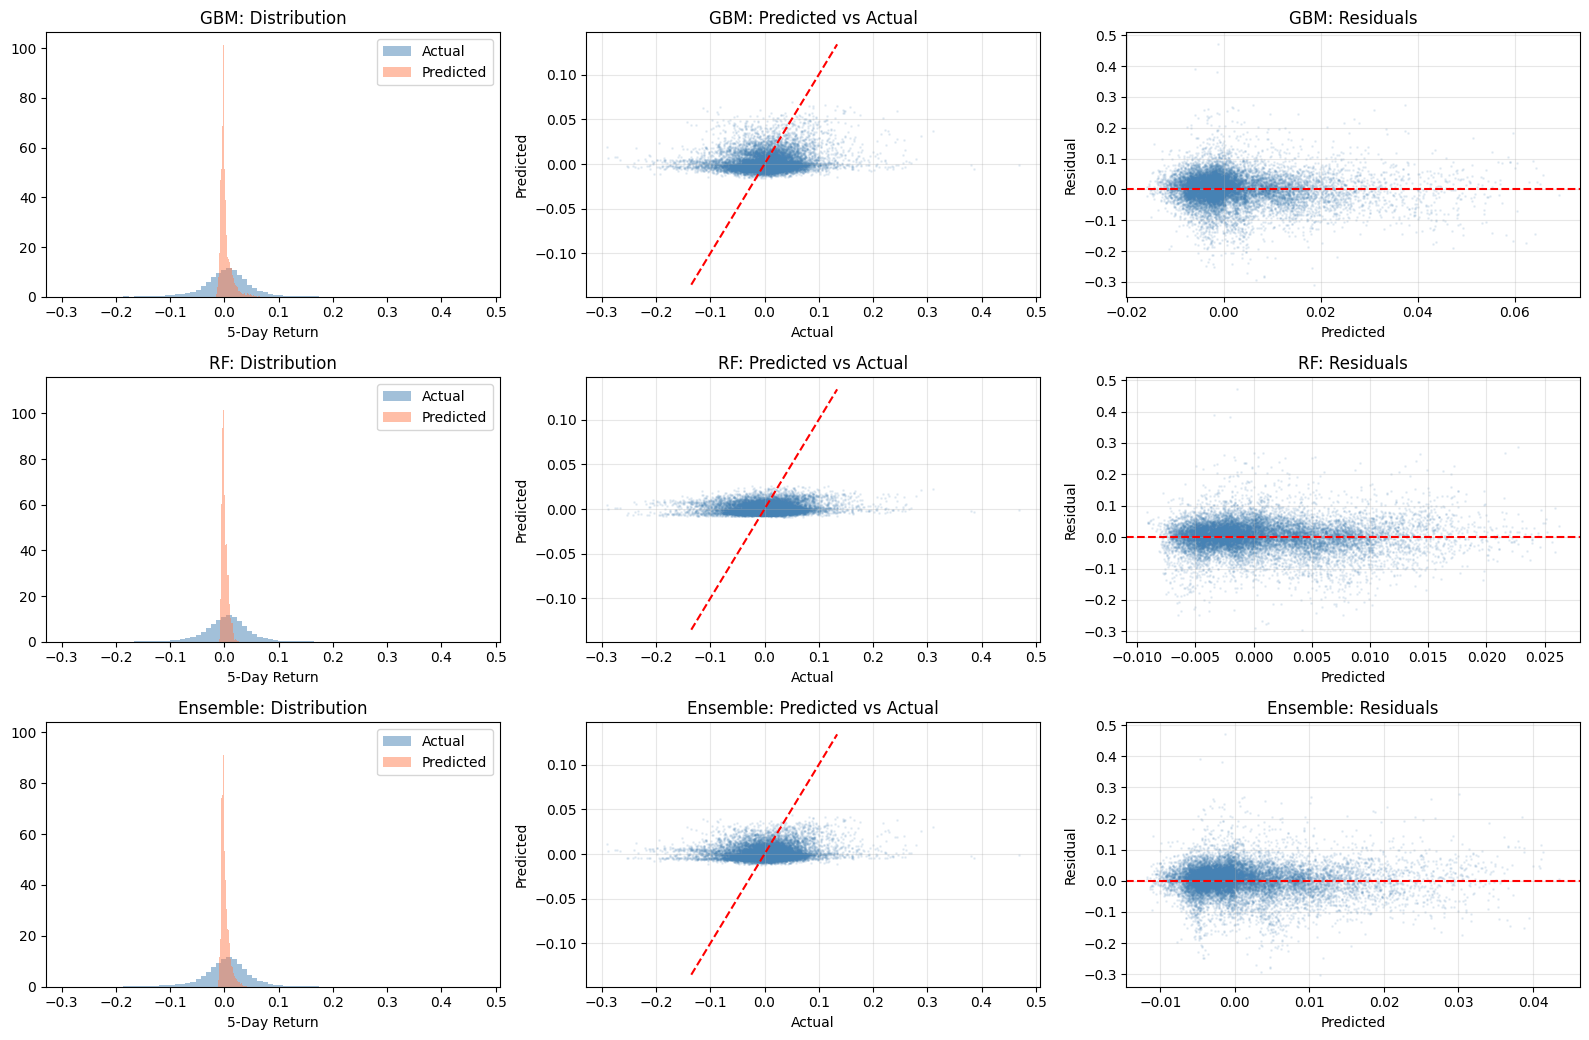

In [ ]:
# ── Prediction vs Actual distributions ──────────────────────────────────────
models = [("GBM", y_pred_gbm), ("RF", y_pred_rf), ("Ensemble", y_pred_ensemble)]
fig, axes = plt.subplots(len(models), 3, figsize=(16, 3.5 * len(models)))

for row, (name, y_pred) in enumerate(models):
    axes[row, 0].hist(y_test, bins=80, alpha=0.5, label="Actual", density=True, color="steelblue")
    axes[row, 0].hist(y_pred, bins=80, alpha=0.5, label="Predicted", density=True, color="coral")
    axes[row, 0].set_title(f"{name}: Distribution")
    axes[row, 0].legend()
    axes[row, 0].set_xlabel(f"{TARGET_HORIZON}-Day Return")

    axes[row, 1].scatter(y_test, y_pred, alpha=0.1, s=1, color="steelblue")
    lims = [y_test.quantile(0.01), y_test.quantile(0.99)]
    axes[row, 1].plot(lims, lims, "r--", lw=1.5)
    axes[row, 1].set_title(f"{name}: Predicted vs Actual")
    axes[row, 1].set_xlabel("Actual"); axes[row, 1].set_ylabel("Predicted")
    axes[row, 1].grid(True, alpha=0.3)

    residuals = y_test - y_pred
    axes[row, 2].scatter(y_pred, residuals, alpha=0.1, s=1, color="steelblue")
    axes[row, 2].axhline(y=0, color="r", ls="--", lw=1.5)
    axes[row, 2].set_title(f"{name}: Residuals")
    axes[row, 2].set_xlabel("Predicted"); axes[row, 2].set_ylabel("Residual")
    axes[row, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

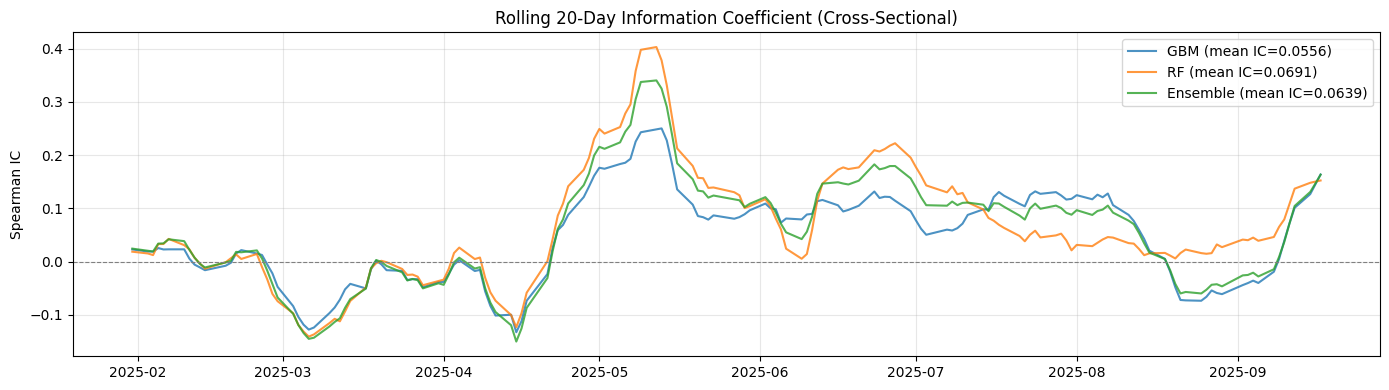

In [ ]:
# ── Rolling IC over time (daily cross-sectional Spearman) ───────────────────
test_results = pd.DataFrame({
    "actual": y_test.values,
    "pred_gbm": y_pred_gbm,
    "pred_rf": y_pred_rf,
    "pred_ensemble": y_pred_ensemble,
}, index=y_test.index)

def rolling_ic(col):
    return test_results.groupby(level="date").apply(
        lambda g: spearmanr(g[col], g["actual"])[0] if len(g) > 5 else np.nan
    )

fig, ax = plt.subplots(figsize=(14, 4))
for col, label in [("pred_gbm", "GBM"), ("pred_rf", "RF"), ("pred_ensemble", "Ensemble")]:
    ic_series = rolling_ic(col)
    ax.plot(pd.to_datetime(ic_series.index), ic_series.rolling(20).mean(),
            label=f"{label} (mean IC={ic_series.mean():.4f})", alpha=0.8)

ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_title("Rolling 20-Day Information Coefficient (Cross-Sectional)")
ax.set_ylabel("Spearman IC")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Feature Importance

**Permutation importance** on GBM — which features, when shuffled, cause the largest increase in test-set RMSE.

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    gbm_pipe, X_test, y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

# ── Top 30 features ────────────────────────────────────────────────────────
top30 = perm_df.head(30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top30)), top30["importance_mean"], xerr=top30["importance_std"],
        color="steelblue", alpha=0.8)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30["feature"], fontsize=9)
ax.invert_yaxis()
ax.set_title("Top 30 Features — Permutation Importance (GBM)")
ax.set_xlabel("Mean RMSE increase when shuffled")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# ── Feature group summary ──────────────────────────────────────────────────
def classify_feature(f):
    if f.startswith("news_emb_"): return "news_embedding"
    if f.startswith("news_"): return "news_sentiment"
    if f.startswith("insider_") or f.startswith("revision_"): return "alternative"
    macro_prefixes = [
        "yc_", "rate_", "vix_", "hy_", "bbb_", "ted_", "credit_", "claims_",
        "unemp_", "sahm_", "oil_", "gold_", "usd_", "mortgage_", "fed_", "nfci_",
        "stress_", "risk_", "policy_", "growth_", "inflation_", "stagflation_",
        "treasury_", "breakeven_", "real_yield_", "consumer_sentiment", "m2_",
        "leading_", "nonfarm_", "continued_", "avg_weekly_", "cpi", "core_", "pce",
        "gas_", "jpy_", "eur_", "gbp_", "housing_", "building_", "permits_",
        "industrial_", "retail_sales_", "durable_", "inv_sales_", "term_premium_",
        "btc_", "copper_", "aggregate_flow", "credit_flow", "safety_flow",
        "risk_appetite", "spy_", "qqq_", "iwm_", "hyg_", "tlt_",
    ]
    if any(f.startswith(p) for p in macro_prefixes): return "macro"
    return "price/tech"

perm_df["group"] = perm_df["feature"].apply(classify_feature)
group_imp = perm_df.groupby("group")["importance_mean"].agg(["sum", "mean", "count"])
print("\nFeature group contributions:")
print(group_imp.sort_values("sum", ascending=False))

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.11/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/_7/_hqwtk652491lqydm38b4z2r0000gp/T/joblib_memmapping_folder_83207_53011f5a98ff492fa000fb08703c18f8_c56c725dd2a24edbbd8ccc475b8eda92 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.11/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 371, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-83207-itsk9kky for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):

KeyboardInterrupt: 

In [35]:
# ── Per-stock performance breakdown ─────────────────────────────────────────
per_stock = test_results.groupby(level="symbol").apply(lambda g: pd.Series({
    "ic": spearmanr(g["pred_ensemble"], g["actual"])[0] if len(g) > 10 else np.nan,
    "dir_acc": ((g["pred_ensemble"] > 0) == (g["actual"] > 0)).mean(),
    "rmse": root_mean_squared_error(g["actual"], g["pred_ensemble"]),
    "n_samples": len(g),
}))

print("Per-stock metrics (sorted by IC):")
per_stock.sort_values("ic", ascending=False)

Per-stock metrics (sorted by IC):


,ic,dir_acc,rmse,n_samples
symbol,,,,
BA,0.367579,0.621469,0.055990,177.0
PYPL,0.351978,0.615819,0.047283,177.0
MA,0.350349,0.542373,0.030955,177.0
NFLX,0.333646,0.598870,0.048599,177.0
HON,0.325862,0.655367,0.031836,177.0
...,...,...,...,...
O,-0.100587,0.378531,0.025253,177.0
LLY,-0.104926,0.367232,0.062125,177.0
JNJ,-0.152893,0.412429,0.026815,177.0


## 9. Portfolio Backtest

Simulate a **long-short portfolio** rebalanced every `TARGET_HORIZON` (5) trading days:
- **Long:** top-quintile stocks by predicted return (buy the best ~17 of 87)
- **Short:** bottom-quintile stocks (sell the worst ~17)
- Equal-weight within each leg, dollar-neutral (long $ = short $)
- Round-trip transaction costs applied on turnover

This is the real test: *"If I actually traded on these predictions, would I make money?"*

In [36]:
# ── Backtest config ─────────────────────────────────────────────────────────
REBAL_FREQ       = TARGET_HORIZON   # rebalance every 5 trading days
TOP_QUANTILE     = 0.2              # long top 20%
BOT_QUANTILE     = 0.2              # short bottom 20%
COST_BPS         = 10               # 10 bps round-trip transaction cost

cost_per_trade   = COST_BPS / 10_000

# ── Build predictions DataFrame ─────────────────────────────────────────────
bt = test_results[["actual", "pred_ensemble"]].copy()
bt = bt.reset_index()
bt["date"] = pd.to_datetime(bt["date"])

# Get unique rebalance dates (every REBAL_FREQ trading days)
all_dates = sorted(bt["date"].unique())
rebal_dates = all_dates[::REBAL_FREQ]
print(f"Test period: {all_dates[0].date()} \u2192 {all_dates[-1].date()}")
print(f"Rebalance dates: {len(rebal_dates)} (every {REBAL_FREQ} trading days)")
print(f"Transaction cost: {COST_BPS} bps round-trip")

Test period: 2025-01-02 → 2025-09-17
Rebalance dates: 36 (every 5 trading days)
Transaction cost: 10 bps round-trip


In [37]:
# ── Run backtest ────────────────────────────────────────────────────────────
portfolio_returns = []
prev_longs = set()
prev_shorts = set()

for rebal_date in rebal_dates:
    day = bt[bt["date"] == rebal_date].copy()
    if len(day) < 10:
        continue

    # Rank stocks by predicted return
    day = day.sort_values("pred_ensemble", ascending=False)
    n_stocks = len(day)
    n_long  = max(1, int(n_stocks * TOP_QUANTILE))
    n_short = max(1, int(n_stocks * BOT_QUANTILE))

    longs  = set(day.head(n_long)["symbol"])
    shorts = set(day.tail(n_short)["symbol"])

    # Actual returns for each leg (equal-weight)
    long_ret  = day[day["symbol"].isin(longs)]["actual"].mean()
    short_ret = day[day["symbol"].isin(shorts)]["actual"].mean()

    # Long-short return (long top, short bottom)
    ls_return = long_ret - short_ret

    # Transaction costs: proportional to turnover
    long_turnover  = len(longs  - prev_longs)  / max(len(longs), 1)
    short_turnover = len(shorts - prev_shorts) / max(len(shorts), 1)
    avg_turnover = (long_turnover + short_turnover) / 2
    cost = avg_turnover * cost_per_trade * 2  # 2 legs

    portfolio_returns.append({
        "date": rebal_date,
        "long_ret": long_ret,
        "short_ret": short_ret,
        "ls_gross": ls_return,
        "ls_net": ls_return - cost,
        "cost": cost,
        "long_turnover": long_turnover,
        "short_turnover": short_turnover,
        "n_long": len(longs),
        "n_short": len(shorts),
    })

    prev_longs = longs
    prev_shorts = shorts

bt_df = pd.DataFrame(portfolio_returns).set_index("date")
print(f"Backtest periods: {len(bt_df)}")
print(f"Mean turnover: {bt_df[['long_turnover','short_turnover']].mean().mean()*100:.1f}%")

Backtest periods: 36
Mean turnover: 40.9%


In [38]:
# ── Summary statistics ──────────────────────────────────────────────────────

def annualise(series, periods_per_year=252/REBAL_FREQ):
    """Annualise return and vol from per-period series."""
    mean_ret = series.mean() * periods_per_year
    vol = series.std() * np.sqrt(periods_per_year)
    sharpe = mean_ret / vol if vol > 0 else 0
    return mean_ret, vol, sharpe

ann_ret_g, ann_vol_g, sharpe_g = annualise(bt_df["ls_gross"])
ann_ret_n, ann_vol_n, sharpe_n = annualise(bt_df["ls_net"])

# Cumulative returns
bt_df["cum_gross"] = (1 + bt_df["ls_gross"]).cumprod()
bt_df["cum_net"]   = (1 + bt_df["ls_net"]).cumprod()

# Max drawdown
def max_drawdown(cum):
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

mdd_g = max_drawdown(bt_df["cum_gross"])
mdd_n = max_drawdown(bt_df["cum_net"])

# Win rate
win_rate = (bt_df["ls_net"] > 0).mean()

# Long-only benchmark
ann_ret_long, ann_vol_long, sharpe_long = annualise(bt_df["long_ret"])

print(f"{'='*65}")
print(f"  PORTFOLIO BACKTEST RESULTS")
print(f"  Rebalance: every {REBAL_FREQ} days | Cost: {COST_BPS} bps | Q: {TOP_QUANTILE:.0%}/{BOT_QUANTILE:.0%}")
print(f"{'='*65}")
print(f"")
print(f"  {'Metric':<30} {'Gross':>10} {'Net':>10}")
print(f"  {'-'*30} {'-'*10} {'-'*10}")
print(f"  {'Ann. Return':<30} {ann_ret_g:>+9.2%} {ann_ret_n:>+9.2%}")
print(f"  {'Ann. Volatility':<30} {ann_vol_g:>9.2%} {ann_vol_n:>9.2%}")
print(f"  {'Sharpe Ratio':<30} {sharpe_g:>10.2f} {sharpe_n:>10.2f}")
print(f"  {'Max Drawdown':<30} {mdd_g:>9.2%} {mdd_n:>9.2%}")
print(f"  {'Win Rate':<30} {'':>10} {win_rate:>9.1%}")
print(f"  {'Total Return':<30} {bt_df['cum_gross'].iloc[-1]-1:>+9.2%} {bt_df['cum_net'].iloc[-1]-1:>+9.2%}")
print(f"")
print(f"  {'Long-only (top quintile):':<30} {ann_ret_long:>+9.2%} ret, {sharpe_long:.2f} SR")
print(f"{'='*65}")

  PORTFOLIO BACKTEST RESULTS
  Rebalance: every 5 days | Cost: 10 bps | Q: 20%/20%

  Metric                              Gross        Net
  ------------------------------ ---------- ----------
  Ann. Return                      +59.98%   +55.86%
  Ann. Volatility                   28.60%    28.62%
  Sharpe Ratio                         2.10       1.95
  Max Drawdown                     -10.85%   -10.97%
  Win Rate                                      69.4%
  Total Return                     +48.96%   +44.67%

  Long-only (top quintile):        +61.86% ret, 2.05 SR


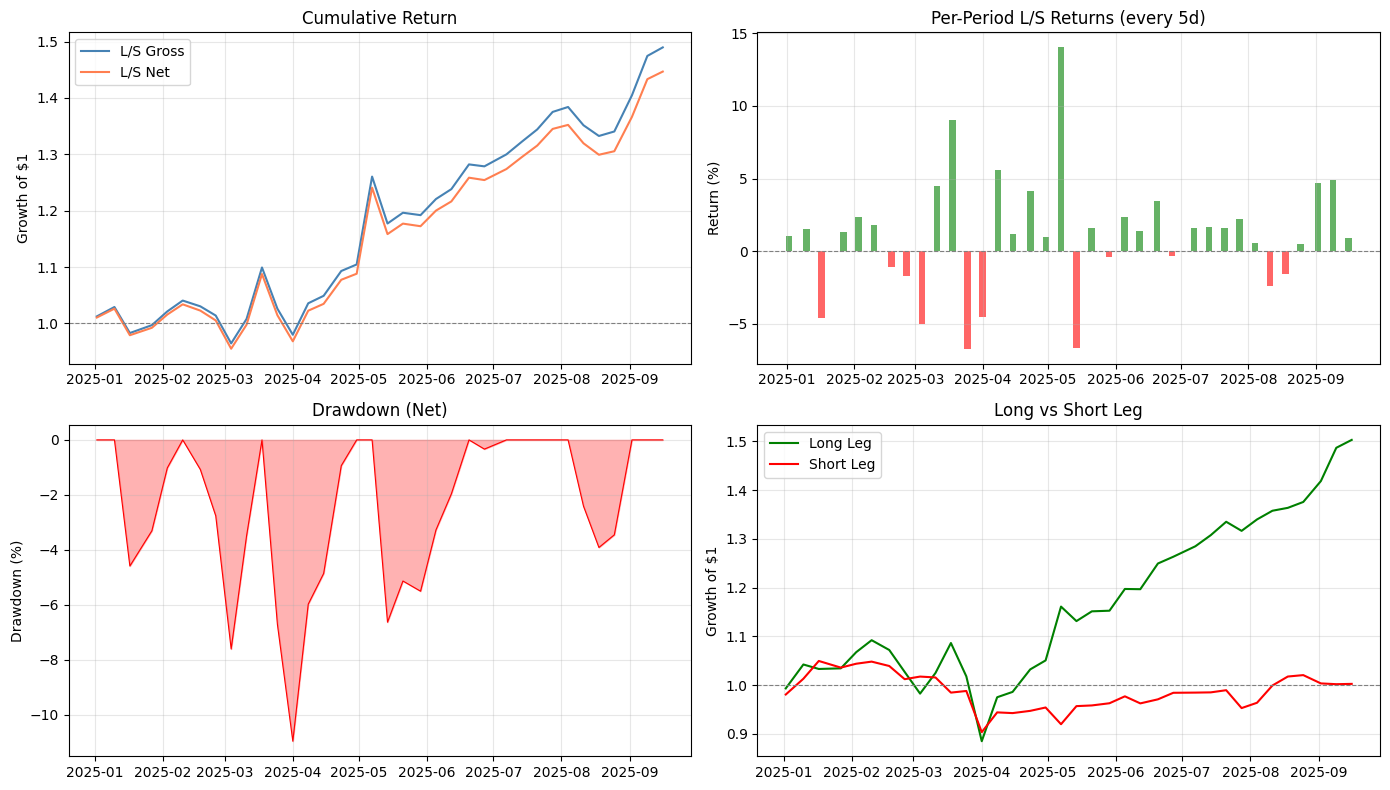

In [39]:
# ── Equity curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Cumulative returns
ax = axes[0, 0]
ax.plot(bt_df.index, bt_df["cum_gross"], label="L/S Gross", color="steelblue", lw=1.5)
ax.plot(bt_df.index, bt_df["cum_net"], label="L/S Net", color="coral", lw=1.5)
ax.axhline(1, color="grey", ls="--", lw=0.8)
ax.set_title("Cumulative Return")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Per-period returns
ax = axes[0, 1]
colors = ["green" if r > 0 else "red" for r in bt_df["ls_net"]]
ax.bar(bt_df.index, bt_df["ls_net"] * 100, color=colors, alpha=0.6, width=3)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_title(f"Per-Period L/S Returns (every {REBAL_FREQ}d)")
ax.set_ylabel("Return (%)")
ax.grid(True, alpha=0.3)

# 3. Drawdown
ax = axes[1, 0]
peak = bt_df["cum_net"].cummax()
dd = (bt_df["cum_net"] - peak) / peak * 100
ax.fill_between(bt_df.index, dd, 0, color="red", alpha=0.3)
ax.plot(bt_df.index, dd, color="red", lw=0.8)
ax.set_title("Drawdown (Net)")
ax.set_ylabel("Drawdown (%)")
ax.grid(True, alpha=0.3)

# 4. Long vs Short leg
ax = axes[1, 1]
cum_long  = (1 + bt_df["long_ret"]).cumprod()
cum_short = (1 + bt_df["short_ret"]).cumprod()
ax.plot(bt_df.index, cum_long, label="Long Leg", color="green", lw=1.5)
ax.plot(bt_df.index, cum_short, label="Short Leg", color="red", lw=1.5)
ax.axhline(1, color="grey", ls="--", lw=0.8)
ax.set_title("Long vs Short Leg")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

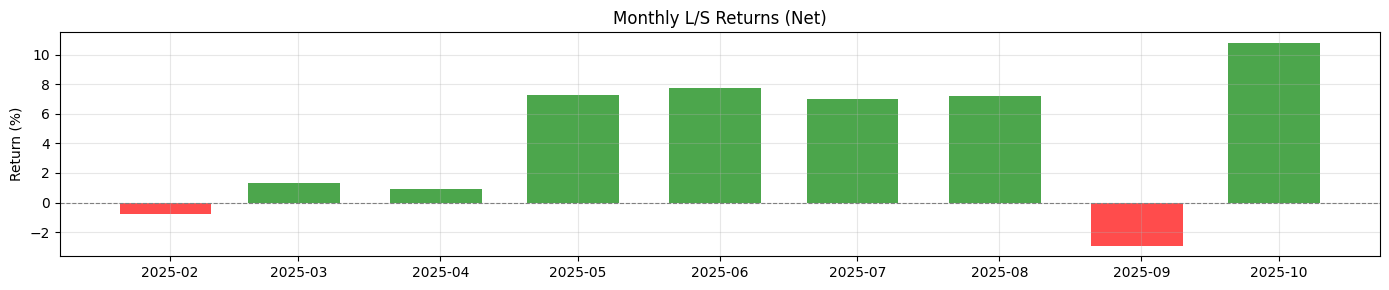


Monthly returns (%):
date        2025-01  2025-02  2025-03  2025-04  2025-05  2025-06  2025-07  2025-08  2025-09
return_pct    -0.77    +1.31    +0.92    +7.25    +7.74    +6.98    +7.23    -2.94   +10.82

Positive months: 7/9


In [40]:
# ── Monthly breakdown ───────────────────────────────────────────────────────
monthly = bt_df["ls_net"].resample("ME").apply(lambda x: (1 + x).prod() - 1)
monthly_pct = monthly * 100

fig, ax = plt.subplots(figsize=(14, 3))
colors = ["green" if r > 0 else "red" for r in monthly_pct]
ax.bar(monthly_pct.index, monthly_pct, color=colors, alpha=0.7, width=20)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_title("Monthly L/S Returns (Net)")
ax.set_ylabel("Return (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print monthly table
monthly_table = monthly_pct.to_frame("return_pct")
monthly_table.index = monthly_table.index.strftime("%Y-%m")
print("\nMonthly returns (%):")
print(monthly_table.T.to_string(float_format=lambda x: f"{x:+.2f}"))
print(f"\nPositive months: {(monthly_pct > 0).sum()}/{len(monthly_pct)}")